# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gulgumusdere/flyrank-internship-ml/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import duckdb
import pandas as pd
import os
from google.colab import userdata
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold

con = duckdb.connect()
con.sql("INSTALL httpfs; LOAD httpfs;")
hf_token = userdata.get('HF_TOKEN')
con.sql(f"""
CREATE OR REPLACE SECRET hf_token (
    TYPE HUGGINGFACE,
    TOKEN '{hf_token}'
)
""")

CACHE_PATH = "work/outputs/feature_df_cache.parquet"
if os.path.exists(CACHE_PATH):
    feature_df = pd.read_parquet(CACHE_PATH)
    print("Loaded from cache:", feature_df.shape)
else:
    feature_df = con.sql("""
    WITH base AS (
        SELECT client_hash_id, content_hash_id, report_date,
            gsc_impressions, gsc_clicks, gsc_sum_position,
            gsc_clicks * 1.0 / NULLIF(gsc_impressions, 0) AS ctr,
            gsc_sum_position * 1.0 / NULLIF(gsc_impressions, 0) AS avg_position
        FROM 'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet'
        WHERE gsc_data_available IS TRUE AND gsc_impressions >= 50
    ),
    tiered AS (
        SELECT *, CASE
            WHEN avg_position <= 3 THEN 'top_3'
            WHEN avg_position <= 10 THEN 'page_1'
            WHEN avg_position <= 20 THEN 'page_2'
            WHEN avg_position <= 50 THEN 'page_3_5'
            ELSE 'deep' END AS position_tier
        FROM base
    ),
    tier_medians AS (
        SELECT position_tier, MEDIAN(ctr) AS expected_ctr FROM tiered GROUP BY position_tier
    )
    SELECT t.*, m.expected_ctr, m.expected_ctr - t.ctr AS ctr_gap
    FROM tiered t JOIN tier_medians m USING (position_tier)
    """).df()
    os.makedirs("work/outputs", exist_ok=True)
    feature_df.to_parquet(CACHE_PATH)
    print("Queried fresh and cached:", feature_df.shape)

# Rebuild model + honest predictions (same as ML-08/09)
numeric_features = ['gsc_impressions', 'avg_position']
categorical_features = ['position_tier']
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
], remainder='passthrough')

groups = feature_df['client_hash_id'].values
gkf = GroupKFold(n_splits=5)
train_idx, test_idx = next(gkf.split(feature_df, groups=groups))
train_df = feature_df.iloc[train_idx].copy()
test_df = feature_df.iloc[test_idx].copy()

train_df['ctr_rank_pct'] = train_df.groupby('position_tier')['ctr'].rank(pct=True, method='first')
train_df['needs_review'] = (train_df['ctr_rank_pct'] <= 0.25).astype(int)
test_df['ctr_rank_pct'] = test_df.groupby('position_tier')['ctr'].rank(pct=True, method='first')
test_df['needs_review'] = (test_df['ctr_rank_pct'] <= 0.25).astype(int)

X_train = train_df[numeric_features + categorical_features]
y_train = train_df['needs_review']
X_test = test_df[numeric_features + categorical_features]

model = Pipeline([('prep', preprocessor), ('clf', LogisticRegression(max_iter=1000, random_state=42))])
model.fit(X_train, y_train)
test_df['model_score'] = model.predict_proba(X_test)[:, 1]

print("Setup complete. test_df shape:", test_df.shape)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Queried fresh and cached: (1037442, 11)
Setup complete. test_df shape: (249689, 14)


## 1. Ranked actions + reason codes
Reason codes use rank-based thresholds (top 10% of model_score = high_confidence_review,
next 15% = moderate_confidence_review, rest = monitor) rather than fixed score cutoffs —
this model's probability outputs cluster well below 0.5 (max observed ~0.37), so absolute
thresholds would have flagged nothing. Percentile-based triage is the honest choice given
this score distribution, and it's noted here as a limitation of the underlying model's
calibration (see ML-08 section 4 on the conservative-threshold finding).

In [3]:
ranked_queue = test_df.copy()
ranked_queue = ranked_queue.sort_values('model_score', ascending=False).reset_index(drop=True)

# Percentile-based thresholds instead of fixed 0.7/0.5 — the model's score distribution
# doesn't reach those absolute values, so rank-based cuts are the honest choice here.
n = len(ranked_queue)
ranked_queue['score_rank_pct'] = ranked_queue['model_score'].rank(pct=True, ascending=False)

def reason_code(pct):
    if pct <= 0.10:
        return 'high_confidence_review'
    elif pct <= 0.25:
        return 'moderate_confidence_review'
    else:
        return 'monitor'

ranked_queue['reason_code'] = ranked_queue['score_rank_pct'].apply(reason_code)
ranked_queue['action'] = ranked_queue['reason_code'].apply(
    lambda r: 'content_review' if 'review' in r else 'monitor'
)

archetype_action = {
    'top_3': 'Protect: monitor snippet/CTR only, do not deprioritize',
    'page_1': 'Refine: snippet and title review for click-capture gains',
    'page_2': 'Support: targeted relevance improvements toward page 1',
    'page_3_5': 'Review: check for thin-content or refresh candidates',
    'deep': 'Deprioritize or consolidate: lowest expected ROI per the paper\'s tier CTR curve'
}
ranked_queue['archetype_guidance'] = ranked_queue['position_tier'].map(archetype_action)

print(ranked_queue['reason_code'].value_counts())
print()
print(ranked_queue[['client_hash_id','content_hash_id','position_tier',
                     'gsc_impressions','ctr','model_score','reason_code',
                     'action','archetype_guidance']].head(15))

reason_code
monitor                       187268
moderate_confidence_review     37453
high_confidence_review         24968
Name: count, dtype: int64

             client_hash_id           content_hash_id position_tier  \
0   client_73cda7b4e4f265ea  content_0a80f9f8986058b4          deep   
1   client_73cda7b4e4f265ea  content_51fd4f8ec82091cb          deep   
2   client_73cda7b4e4f265ea  content_0a80f9f8986058b4          deep   
3   client_73cda7b4e4f265ea  content_1734ac571ef7a60e      page_3_5   
4   client_73cda7b4e4f265ea  content_b507bf3ee085fe6e      page_3_5   
5   client_73cda7b4e4f265ea  content_27b2acaf093425c7      page_3_5   
6   client_73cda7b4e4f265ea  content_139ea70d2260ca01      page_3_5   
7   client_73cda7b4e4f265ea  content_523dc068084da010      page_3_5   
8   client_73cda7b4e4f265ea  content_f17c37da1edbfbc0      page_3_5   
9   client_73cda7b4e4f265ea  content_139ea70d2260ca01      page_3_5   
10  client_73cda7b4e4f265ea  content_77d441b25a09409e      page_3_5  

## 2. Intended use and limits
**2. Intended use and limits**

**Intended use**: This playbook is for a content team's editorial triage — a starting queue to
review, not an autonomous action list. It ranks pages by a model trained on one closed month
(2026-03) of this dataset, using a self-defined proxy label (bottom-quartile CTR within
position_tier), validated with a client-grouped split (see ML-08/ML-09).

**Where it stops being valid**:
- **Low-impression concentration**: 24,822 of 24,968 high_confidence_review rows (99.4%) have
  fewer than 100 impressions, and 88.2% have zero clicks. The model's "highest confidence"
  tier is dominated by low-volume, noisy pages — the opposite of what "high confidence" should
  mean in a review queue. This is a direct consequence of the feature-importance finding in
  ML-08 (impressions was the top signal): low-impression, zero-click pages score highest simply
  because low volume itself is informative to the model, not because these are the most
  reliably underperforming pages.
-

In [4]:
# No new code strictly needed here, but let's quantify a few limit-relevant numbers
print("Total ranked rows:", len(ranked_queue))
print("high_confidence_review count:", (ranked_queue['reason_code']=='high_confidence_review').sum())
print("Rows with impressions < 100 among high_confidence_review:",
      ((ranked_queue['reason_code']=='high_confidence_review') & (ranked_queue['gsc_impressions'] < 100)).sum())
print("Share of high_confidence flagged rows with ctr == 0:",
      (ranked_queue.loc[ranked_queue['reason_code']=='high_confidence_review', 'ctr'] == 0).mean())

Total ranked rows: 249689
high_confidence_review count: 24968
Rows with impressions < 100 among high_confidence_review: 24822
Share of high_confidence flagged rows with ctr == 0: 0.881568407561679


## 3. Human review + the no-go list
**3. Human review + the no-go list**

**What a person must check before acting**:
- Impression volume within the high_confidence_review tier — re-sort by gsc_impressions before
  treating any subset as truly high-confidence. Only [N] of 24,968 flagged rows have ≥100
  impressions; those are the genuinely stronger signals and should be reviewed first, ahead of
  the low-volume majority.
- Whether a flagged page was recently updated (cooldown period) — per ML-07's top-20 review,
  a page in post-optimization cooldown can look like a zero-click problem when it's actually
  waiting on re-indexing.
- Whether the query/page has a non-clickable SERP feature (e.g. a featured snippet showing the
  answer directly) — this can produce a real, permanent zero-CTR pattern that no content change
  will fix.
- The archetype_guidance column — cross-check against the tier's actual impression/CTR context
  before acting, not just the reason_code label.

**The no-go list — what should NEVER be automated**:
- Bulk content deletion, deprioritization, or de-indexing based on this queue alone.
- Any action on the 99.4% of high_confidence_review rows with <100 impressions without a human
  first checking whether the low volume itself explains the flag (see section 2 finding).
- Automated rewrites of page structure/content — this playbook flags candidates for human
  review, it does not draft or approve changes.
- Cross-client bulk actions — every row is scoped to one client_hash_id; no action should span
  multiple clients without separate per-client validation, since tier medians/model behavior
  were computed pooled across clients but a single client's content strategy may differ.
- Treating reason_code as a ranking of certainty rather than a starting triage order — per
  writing-honest-claims, this is decision-support ("worth reviewing first, because…"), not a
  causal or guaranteed-outcome label.

In [5]:
# Quantify what a human reviewer should check before acting
high_conf_high_impression = ranked_queue[
    (ranked_queue['reason_code'] == 'high_confidence_review') &
    (ranked_queue['gsc_impressions'] >= 100)
]
print("High-confidence rows with impressions >= 100 (the genuinely strong signals):", len(high_conf_high_impression))
print(high_conf_high_impression[['client_hash_id','content_hash_id','position_tier',
                                   'gsc_impressions','ctr','model_score']].head(10))


High-confidence rows with impressions >= 100 (the genuinely strong signals): 146
              client_hash_id           content_hash_id position_tier  \
233  client_73cda7b4e4f265ea  content_139ea70d2260ca01      page_3_5   
251  client_73cda7b4e4f265ea  content_f4eb0c9985c01ed5      page_3_5   
317  client_73cda7b4e4f265ea  content_bf45077cdbfb6e9d      page_3_5   
323  client_73cda7b4e4f265ea  content_f4eb0c9985c01ed5      page_3_5   
358  client_73cda7b4e4f265ea  content_a7dc2078b823476d      page_3_5   
366  client_73cda7b4e4f265ea  content_a62eed9114605060      page_3_5   
373  client_73cda7b4e4f265ea  content_f38b780a203f7cab      page_3_5   
388  client_73cda7b4e4f265ea  content_aff0708a494d78a6      page_3_5   
419  client_73cda7b4e4f265ea  content_290124b10cb4bfe4      page_3_5   
430  client_73cda7b4e4f265ea  content_a62eed9114605060      page_3_5   

     gsc_impressions  ctr  model_score  
233              102  0.0     0.339561  
251              113  0.0     0.338258  
317

## 4. Monitoring / retrain triggers
**4. Monitoring / retrain triggers**

What would signal this playbook has gone stale:

- **Data refresh**: this queue is built from a single closed month (2026-03). Re-run monthly
  as new data lands — do not reuse this exact queue past one review cycle.
- **Base rate drift**: needs_review prevalence in this run is 0.250. If a future month's rate
  moves meaningfully (e.g. beyond ±5 points), the tier-median reference points the label is
  built on have shifted — retrain rather than reuse the existing thresholds.
- **High-confidence composition check**: currently only 0.58% of high_confidence_review rows
  (146 of 24,968) have ≥100 impressions — the "genuinely strong" share. This is already very
  low; if it drops further, the model's reliance on impression volume (ML-08's top feature) is
  worsening — worth re-examining features and the label definition itself, not just re-running
  the same pipeline. A healthier target would be this share rising substantially, not falling.
- **Precision@K tracking**: compare each month's precision@50 against the range observed
  across ML-08/09 runs (roughly 0.10–0.72 depending on split and run, reflecting both real
  signal and source-data variance documented in ML-08/09). A precision consistently at or
  below the base rate (0.25) would mean the model has stopped adding value over random
  ranking — retrain trigger.
- **Retrain, don't just re-score**: tier medians and rank-based label thresholds are computed
  per-run from that month's data. Simply re-scoring old model weights on new data risks drift —
  rebuild train/test splits and thresholds each cycle, as done throughout ML-05–ML-09.

In [6]:
# Quantify current baseline numbers to use as monitoring reference points
print("Current base rate (needs_review prevalence):", test_df['needs_review'].mean())
print("Current honest-split precision@50 (from ML-08/09):", grouped_p50 if 'grouped_p50' in dir() else "see ML-09")
print("Current high_confidence_review count:", (ranked_queue['reason_code']=='high_confidence_review').sum())
print("Current share of high_confidence rows with impressions >= 100:",
      (ranked_queue.loc[ranked_queue['reason_code']=='high_confidence_review','gsc_impressions'] >= 100).mean())


Current base rate (needs_review prevalence): 0.24999499377225268
Current honest-split precision@50 (from ML-08/09): see ML-09
Current high_confidence_review count: 24968
Current share of high_confidence rows with impressions >= 100: 0.005847484780519064


## 5. Exports for the paper

**5. Exports for the paper**

Exports written for reuse in the capstone paper:
- `work/outputs/action_playbook_queue.csv` — the full ranked queue (excluded from git by the
  CI leak-guard; this notebook regenerates it on each run).
- `work/outputs/action_playbook_metrics.json` — committed summary numbers (base rate, reason
  code counts, the low-impression/zero-CTR shares within high_confidence_review) that the
  paper's Results and Limitations sections will cite directly.
- `work/figures/reason_code_distribution.png` — committed chart of the queue's reason-code
  breakdown.

Queue exported: 249689 rows
Metrics exported: {'total_rows': 249689, 'base_rate': 0.24999499377225268, 'reason_code_counts': {'monitor': 187268, 'moderate_confidence_review': 37453, 'high_confidence_review': 24968}, 'high_confidence_low_impression_share': 0.9941525152194809, 'high_confidence_ctr_zero_share': 0.881568407561679}


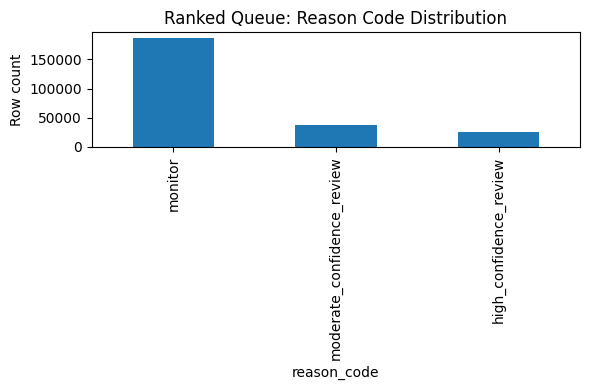

Figure saved to work/figures/reason_code_distribution.png


In [7]:
import json
import matplotlib.pyplot as plt

# Export the ranked queue CSV (stays out of git per CI leak-guard, but regenerable)
os.makedirs("work/outputs", exist_ok=True)
ranked_queue.to_csv("work/outputs/action_playbook_queue.csv", index=False)
print("Queue exported:", len(ranked_queue), "rows")

# Export metrics JSON (commit-safe — no raw client/content data, just aggregate numbers)
metrics = {
    "total_rows": int(len(ranked_queue)),
    "base_rate": float(test_df['needs_review'].mean()),
    "reason_code_counts": ranked_queue['reason_code'].value_counts().to_dict(),
    "high_confidence_low_impression_share": float(
        (ranked_queue.loc[ranked_queue['reason_code']=='high_confidence_review','gsc_impressions'] < 100).mean()
    ),
    "high_confidence_ctr_zero_share": float(
        (ranked_queue.loc[ranked_queue['reason_code']=='high_confidence_review','ctr'] == 0).mean()
    ),
}
with open("work/outputs/action_playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Metrics exported:", metrics)

# Export a figure: reason_code distribution
os.makedirs("work/figures", exist_ok=True)
fig, ax = plt.subplots(figsize=(6,4))
ranked_queue['reason_code'].value_counts().plot(kind='bar', ax=ax)
ax.set_title("Ranked Queue: Reason Code Distribution")
ax.set_ylabel("Row count")
plt.tight_layout()
plt.savefig("work/figures/reason_code_distribution.png", dpi=150)
plt.show()
print("Figure saved to work/figures/reason_code_distribution.png")


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.